**SNP density per 10kb window and outlier plots for each species**


Processing bpertussis...
  Saved: bpertussis_snps_per_sample.png

Processing cjejuni...
  Saved: cjejuni_snps_per_sample.png

Processing ecoli...
  Saved: ecoli_snps_per_sample.png

Processing hinfluenzae...
  Saved: hinfluenzae_snps_per_sample.png

Processing kpneumoniae...
  Saved: kpneumoniae_snps_per_sample.png

Processing lmonocytogenesA...
  Saved: lmonocytogenesA_snps_per_sample.png

Processing mtuberculosis...
  Saved: mtuberculosis_snps_per_sample.png

Processing nmeningitidis...
  Saved: nmeningitidis_snps_per_sample.png

Processing paeruginosa...
  Saved: paeruginosa_snps_per_sample.png

Processing sagalactiae...
  Saved: sagalactiae_snps_per_sample.png

Processing saureus...
  Saved: saureus_snps_per_sample.png

Processing sepidermidis...
  Saved: sepidermidis_snps_per_sample.png

Processing spneumoniae...
  Saved: spneumoniae_snps_per_sample.png

Processing styphimurium...
  Saved: styphimurium_snps_per_sample.png


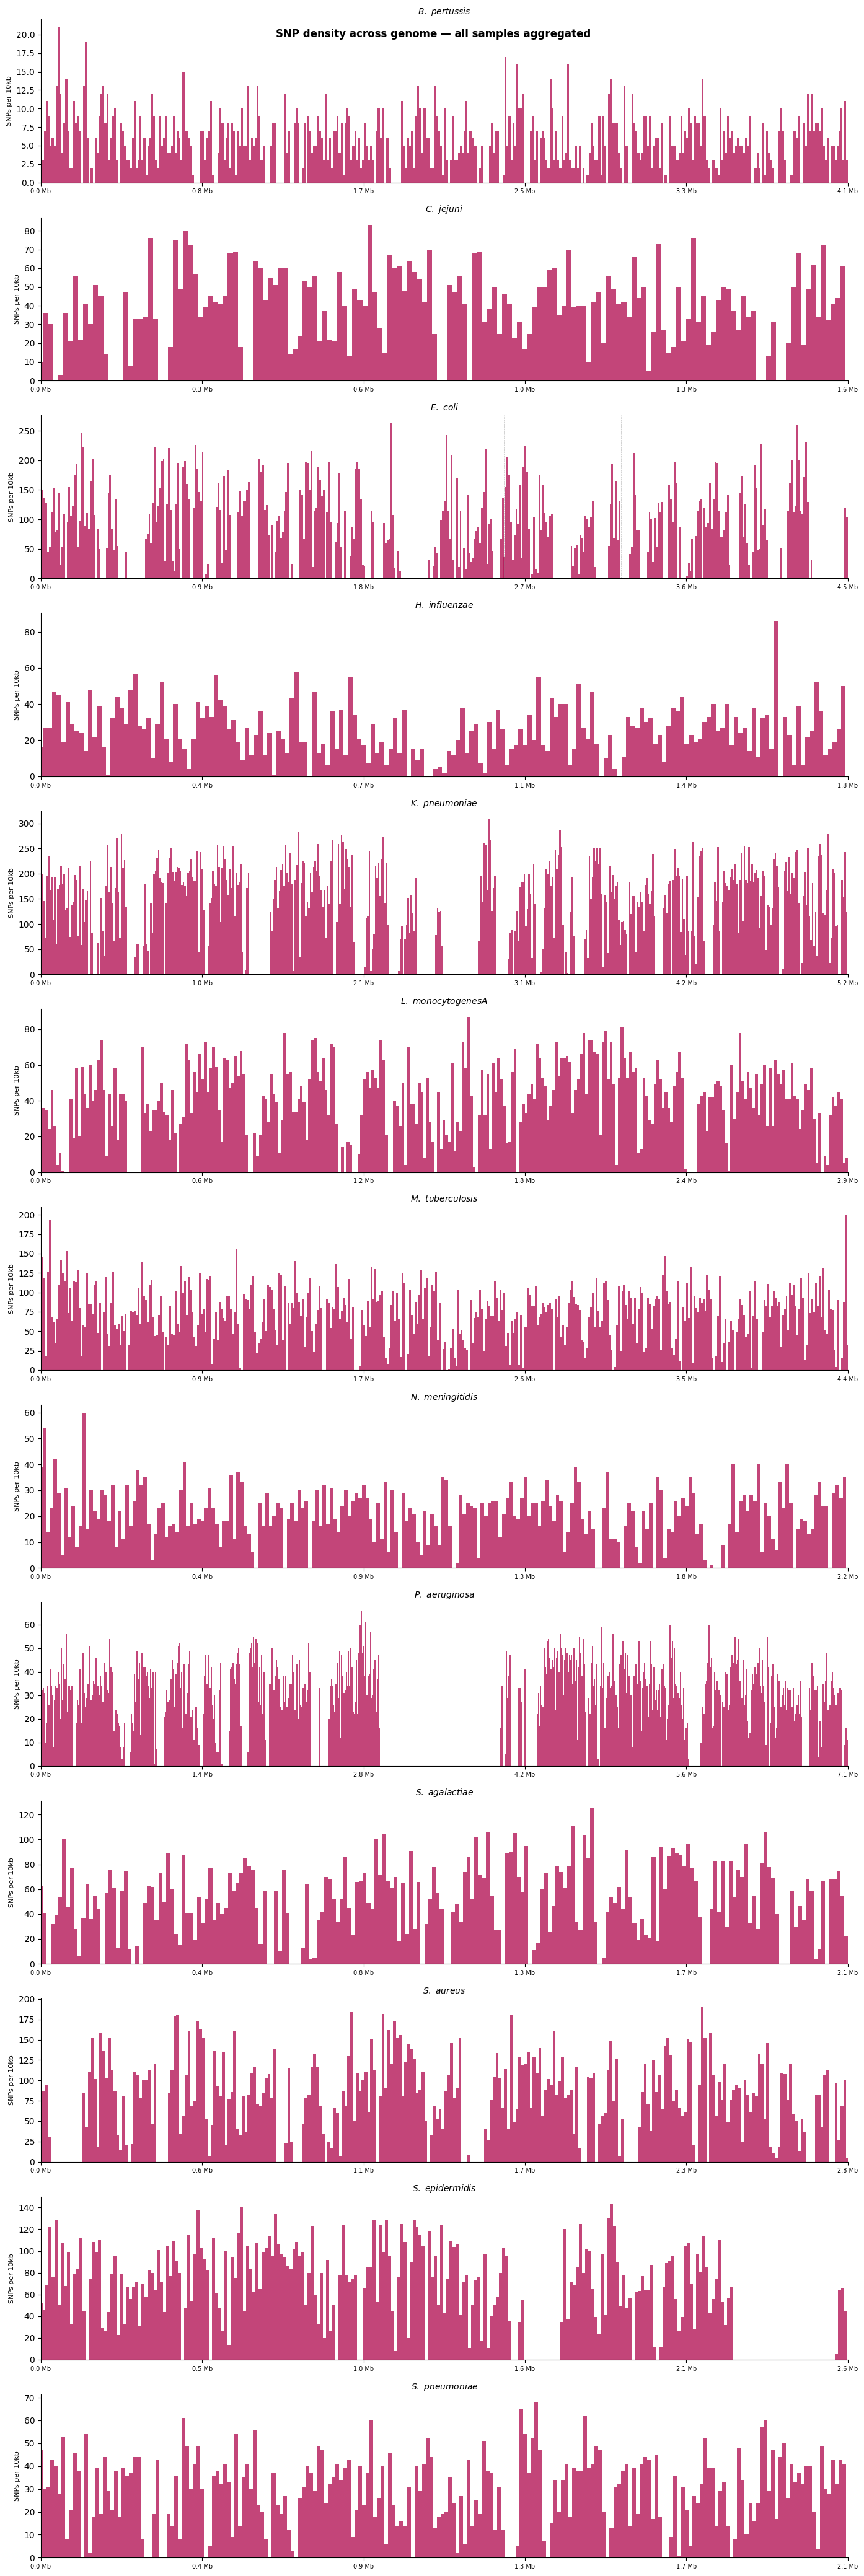


SNP density plot saved to /home/jovyan/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/charts/investigations/outlier_plots/snp_density_genome.png


In [84]:
import os
import glob
import re
import collections
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import math

# paths
processed_folder = os.path.expanduser(
    "~/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/"
)
outlier_folder = os.path.join(processed_folder, "charts", "investigations", "outlier_plots")
os.makedirs(outlier_folder, exist_ok=True)

BIN_SIZE = 10000  # 10 kb

# define colour, format species name and find species list from vcf
ROCKET           = sns.color_palette("rocket", 10)
species_colour   = sns.color_palette("rocket", 8)[3]
colour_outlier   = ROCKET[7]
colour_threshold = ROCKET[5]
colour_mean      = ROCKET[1]

def format_species_name(name):
    genus_initial = name[0].upper()
    rest          = name[1:]
    return f"$\\it{{{genus_initial}.\\ {rest}}}$"

all_vcf_files = sorted(glob.glob(os.path.join(processed_folder, "*_singles_filtered.vcf")))
all_species   = [os.path.basename(f).replace("_singles_filtered.vcf", "") for f in all_vcf_files]

##################
#SNP outlier plots per species
#search through filtered vcf to find mutation counts
for vcf_file in all_vcf_files:
    species_name = os.path.basename(vcf_file).replace("_singles_filtered.vcf", "")
    print(f"\nProcessing {species_name}...")

    samples    = []
    contigs    = set()
    snp_counts = collections.defaultdict(int)

    with open(vcf_file, "r") as f:
        for line in f:
            if line.startswith("#CHROM"):
                samples = line.strip().split("\t")[9:]
                continue
            elif line.startswith("#"):
                continue
            cols = line.strip().split("\t")
            contigs.add(cols[0])
            for i, gt in enumerate(cols[9:]):
                if gt.split(":")[0] in ("1", "1/1", "0/1", "1|0", "0|1"):
                    snp_counts[samples[i]] += 1

    sorted_samples = sorted(samples, key=lambda s: snp_counts[s])
    counts         = [snp_counts[s] for s in sorted_samples]
    mean           = np.mean(counts)
    std            = np.std(counts)
    threshold      = mean + 3 * std
  
    point_colours = [colour_outlier if c > threshold else species_colour
                     for c in counts]
    #plot dot graph with threshold lines
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.scatter(range(len(sorted_samples)), counts,
               c=point_colours, s=5, alpha=0.7, linewidths=0)
    ax.axhline(y=threshold, color=colour_threshold, linewidth=1,
               linestyle="--", label=f"Mean + 3SD ({threshold:.0f})")
    ax.axhline(y=mean, color=colour_mean, linewidth=1,
               linestyle="--", label=f"Mean ({mean:.0f})")
    ax.set_title(
        f"{format_species_name(species_name)} — SNPs per sample ({len(contigs)} contig(s))",
        fontsize=12, fontweight="bold"
    )
    ax.set_xlabel("Samples (sorted by SNP count)", fontsize=10)
    ax.set_ylabel("Number of SNPs", fontsize=10)
    ax.set_xticks([])
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()

    output_path = os.path.join(outlier_folder, f"{species_name}_snps_per_sample.png")
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  Saved: {species_name}_snps_per_sample.png")

#next plots are density plots, same process as before but look per 10kb bin
fig, axes = plt.subplots(13, 1,
                         figsize=(14, 42),
                         sharex=False,
                         facecolor="white")


for ax, vcf_file in zip(axes, all_vcf_files):
    species_name   = os.path.basename(vcf_file).replace("_singles_filtered.vcf", "")
    contig_lengths = {}
    bin_counts     = collections.Counter()

    with open(vcf_file, "r") as f:
        for line in f:
            if line.startswith("##contig"):
                m = re.search(r'ID=([^,>]+).*length=(\d+)', line)
                if m:
                    contig_lengths[m.group(1)] = int(m.group(2))
                continue
            if line.startswith("#"):
                continue
            cols       = line.strip().split("\t")
            chrom, pos = cols[0], int(cols[1])
            contig_lengths[chrom] = max(contig_lengths.get(chrom, 0), pos)
            bin_counts[(chrom, (pos // BIN_SIZE) * BIN_SIZE)] += 1
    #adds found values to graph
    sorted_contigs = sorted(contig_lengths.keys())
    offsets        = {}
    cumulative     = 0
    for ctg in sorted_contigs:
        offsets[ctg] = cumulative
        cumulative   += contig_lengths[ctg]
    genome_length = cumulative

    x_vals = [offsets[chrom] + win for (chrom, win) in bin_counts]
    y_vals = [bin_counts[(chrom, win)] for (chrom, win) in bin_counts]
    order  = np.argsort(x_vals)
    x_vals = np.array(x_vals)[order]
    y_vals = np.array(y_vals)[order]
                           
#shows grey line at each contig
    for ci, ctg in enumerate(sorted_contigs):
        if ci > 0:
            ax.axvline(offsets[ctg], color="grey", linewidth=0.5,
                       linestyle="--", alpha=0.5)

    ax.bar(x_vals, y_vals, width=BIN_SIZE, color=species_colour, alpha=0.8)
    ax.set_xlim(0, genome_length)
    ax.set_ylim(bottom=0)

    ticks = np.linspace(0, genome_length, 6)
    ax.set_xticks(ticks)
    if genome_length > 500_000:
        ax.set_xticklabels([f"{t/1e6:.1f} Mb" for t in ticks], fontsize=7)
    else:
        ax.set_xticklabels([f"{int(t/1000)}kb" for t in ticks], fontsize=7)

    ax.set_ylabel("SNPs per 10kb", fontsize=8)
    ax.set_title(format_species_name(species_name), fontsize=10, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("SNP density across genome — all samples aggregated",
             fontsize=12, fontweight="bold")
plt.tight_layout()
density_path = os.path.join(outlier_folder, "snp_density_genome.png")
plt.savefig(density_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSNP density plot saved to {density_path}")

**Finding Ts/Tv from Ruis et al., 2023 using supp. data**

In [62]:
import pandas as pd

df = os.path.expanduser(
    "~/shared-team/2025-masters-project/people/eleanor/original_and_processed_files/processed_c/charts/investigations/41467_2023_42916_MOESM5_ESM.xlsx")
df = pd.read_excel(df, header=1)
df = df.set_index("Substitution")

def calc_tstv(col):
    ts = col[[i for i in col.index if ("[C>T]" in i or "[T>C]" in i)]].sum()
    tv = col[[i for i in col.index if ("[C>A]" in i or "[C>G]" in i or "[T>A]" in i or "[T>G]" in i)]].sum()
    return round(ts / tv, 4) if tv > 0 else None

species_of_interest = {
    "S_pneumoniae": ["S_pneumoniae_GPSC1", "S_pneumoniae_GPSC2", "S_pneumoniae_GPSC3", "S_pneumoniae_GPSC6", "S_pneumoniae_GPSC54"],
    "S_agalactiae": ["S_agalactiae_CC1", "S_agalactiae_CC10", "S_agalactiae_CC17", "S_agalactiae_CC19", "S_agalactiae_CC23"],
    "S_aureus": ["S_aureus_ST22", "S_aureus_ST239", "S_aureus_ST772", "S_aureus_CC398"],
    "S_epidermidis": ["S_epidermidis_groupA", "S_epidermidis_groupB", "S_epidermidis_groupC"],
    "S_typhimurium": ["S_typhimurium"],
    "C_jejuni": ["C_jejuni_cluster2", "C_jejuni_cluster5", "C_jejuni_cluster6", "C_jejuni_cluster7", "C_jejuni_cluster8"],
    "K_pneumoniae": ["K_pneumoniae_ST11", "K_pneumoniae_ST23", "K_pneumoniae_ST101", "K_pneumoniae_ST147", "K_pneumoniae_ST258_512"],
    "N_meningitidis": ["N_meningitidis_cluster1", "N_meningitidis_cluster2", "N_meningitidis_urethritis"],
    "E_coli": ["E_coli_lineage11", "E_coli_lineage12", "E_coli_lineage14", "E_coli_lineage34"],
    "H_influenzae": ["H_influenzae_Hib"],
    "P_aeruginosa": ["P_aeruginosa_ST17", "P_aeruginosa_ST111", "P_aeruginosa_ST146", "P_aeruginosa_ST175", "P_aeruginosa_ST253"],
}

for species, clades in species_of_interest.items():
    print(f"\n{species}")
    print(f"  {'Clade':<35} {'Ts sum':>10} {'Tv sum':>10} {'Ts/Tv':>8}")
    print(f"  {'-'*65}")
    ratios = []
    for clade in clades:
        if clade in df.columns:
            col = df[clade]
            ts = col[[i for i in col.index if ("[C>T]" in i or "[T>C]" in i)]].sum()
            tv = col[[i for i in col.index if ("[C>A]" in i or "[C>G]" in i or "[T>A]" in i or "[T>G]" in i)]].sum()
            ratio = round(ts/tv, 4)
            ratios.append(ratio)
            print(f"  {clade:<35} {ts:>10.4f} {tv:>10.4f} {ratio:>8.4f}")
    mean = round(sum(ratios)/len(ratios), 4)
    print(f"  {'Mean':<35} {'':>10} {'':>10} {mean:>8.4f}")


S_pneumoniae
  Clade                                   Ts sum     Tv sum    Ts/Tv
  -----------------------------------------------------------------
  S_pneumoniae_GPSC1                      0.7509     0.2491   3.0150
  S_pneumoniae_GPSC2                      0.6820     0.3180   2.1444
  S_pneumoniae_GPSC3                      0.7494     0.2506   2.9901
  S_pneumoniae_GPSC6                      0.7497     0.2503   2.9951
  S_pneumoniae_GPSC54                     0.7366     0.2634   2.7961
  Mean                                                        2.7881

S_agalactiae
  Clade                                   Ts sum     Tv sum    Ts/Tv
  -----------------------------------------------------------------
  S_agalactiae_CC1                        0.7146     0.2854   2.5039
  S_agalactiae_CC10                       0.7479     0.2521   2.9663
  S_agalactiae_CC17                       0.7197     0.2803   2.5679
  S_agalactiae_CC19                       0.7371     0.2629   2.8034
  S_agal